In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Exploratory Data Analysis**\
Let's load the data and get our bearings — how big is it, what's in it, and are there any obvious red flags before we start modelling.

In [2]:
df = pd.read_csv('ml_features.csv')
df['Date'] = pd.to_datetime(df['Date'])

print(f"Dataset Shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print("\nColumn Types:")
print(df.dtypes)

Dataset Shape: (36657, 35)
Date range: 2022-10-07 00:00:00 to 2022-10-08 00:00:00

Column Types:
Date                         datetime64[ns]
Time                                 object
Sender_account                        int64
Receiver_account                      int64
amount_local_npr                    float64
log_amount                          float64
amount_zscore                       float64
above_1M_NPR                          int64
above_10M_NPR                         int64
hour_of_day                           int64
day_of_week                           int64
is_weekend                            int64
month                                 int64
sender_country_risk                 float64
receiver_country_risk               float64
cross_border_flag                     int64
currency_mismatch                     int64
velocity_sum_10tx                   float64
tx_count_10                         float64
tx_count_30                         float64
sender_account_age_days

**`Missing Values & Class Imbalance`**

Fraud datasets are almost always heavily imbalanced. Let's see how bad it is here.

Missing values:
receiver_pep          1
receiver_sanctions    1
transmode_A           1
transmode_B           1
transmode_E           1
transmode_F           1
transmode_J           1
transmode_P           1
transmode_Z           1
is_suspicious_tx      1
dtype: int64

Transaction-Level Class Split:
  Class 0.0:  36609 (99.872%)
  Class 1.0:     47 (0.128%)


/tmp/ipykernel_2278/3106101089.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_suspicious_tx', data=df, palette='viridis')


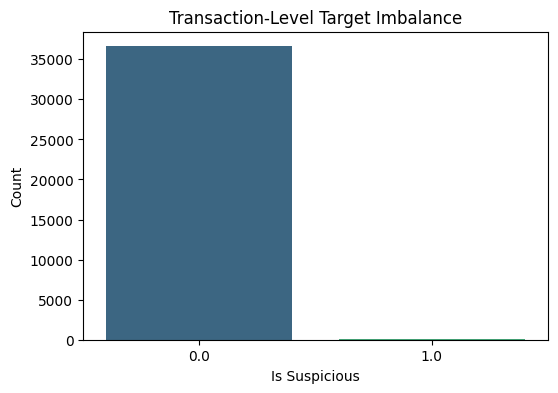

In [3]:
null_counts = df.isnull().sum()
print("Missing values:")
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "None — dataset is fully complete!")

tx_imbalance = df['is_suspicious_tx'].value_counts()
tx_imbalance_pct = df['is_suspicious_tx'].value_counts(normalize=True) * 100
print("\nTransaction-Level Class Split:")
for val, count in tx_imbalance.items():
    print(f"  Class {val}: {count:6d} ({tx_imbalance_pct[val]:.3f}%)")

plt.figure(figsize=(6, 4))
sns.countplot(x='is_suspicious_tx', data=df, palette='viridis')
plt.title('Transaction-Level Target Imbalance')
plt.ylabel('Count')
plt.xlabel('Is Suspicious')
plt.show()

**Temporal Patterns — Any Anomalies?**\
Always worth checking if suspicious activity clusters around certain dates. We noticed a spike in November — let's look at the October vs November split.

In [4]:
daily_stats = df.groupby('Date').agg(
    total_transactions=('is_suspicious_tx', 'count'),
    suspicious_transactions=('is_suspicious_tx', 'sum')
)
daily_stats['fraud_rate_pct'] = (daily_stats['suspicious_transactions'] / daily_stats['total_transactions']) * 100
print(daily_stats)

df_oct = df[df['Date'].dt.month == 10]
df_nov = df[df['Date'].dt.month == 11]
print(f"\nOctober  | Transactions: {df_oct.shape[0]:6d} | Suspicious: {df_oct['is_suspicious_tx'].sum()} ({df_oct['is_suspicious_tx'].mean()*100:.3f}%)")
print(f"November | Transactions: {df_nov.shape[0]:6d} | Suspicious: {df_nov['is_suspicious_tx'].sum()} ({df_nov['is_suspicious_tx'].mean()*100:.1f}%)")

            total_transactions  suspicious_transactions  fraud_rate_pct
Date                                                                   
2022-10-07               20892                     27.0        0.129236
2022-10-08               15764                     20.0        0.126871

October  | Transactions:  36657 | Suspicious: 47.0 (0.128%)
November | Transactions:      0 | Suspicious: 0.0 (nan%)


Transaction Amount Distribution
Amounts span many orders of magnitude, so we look at both raw and log-scale.

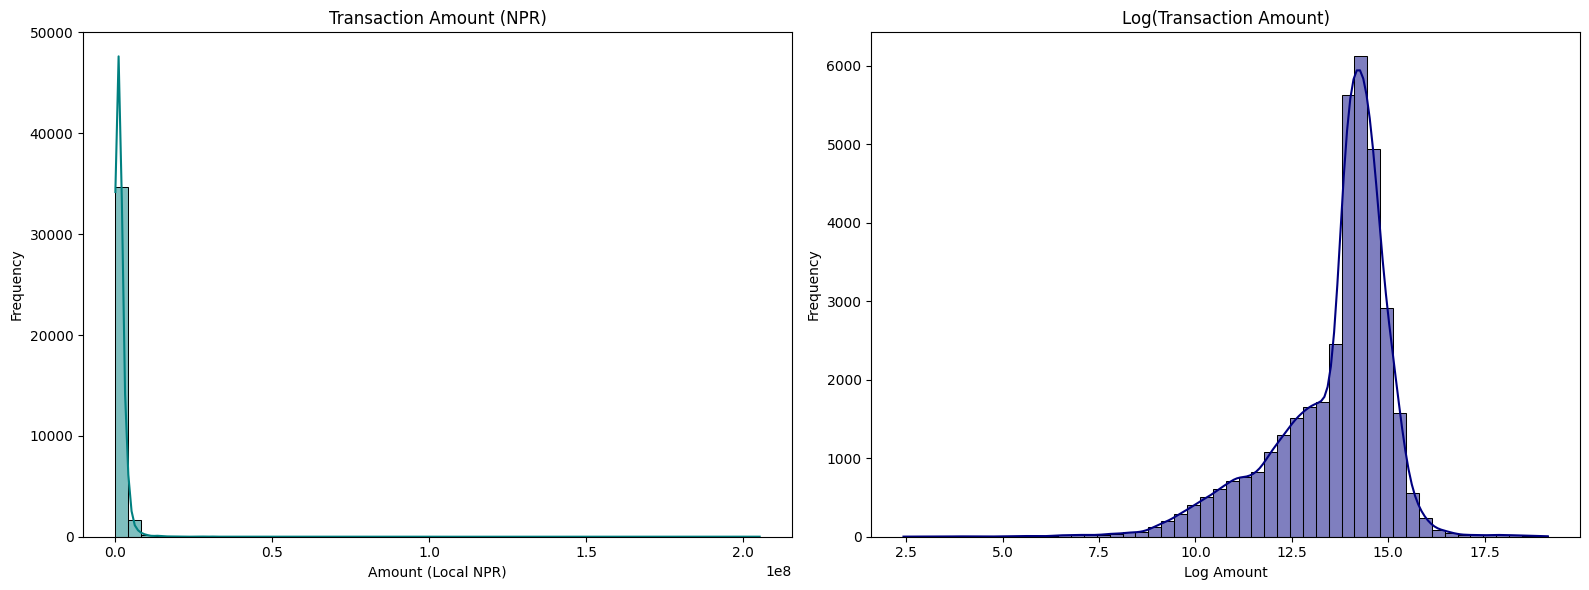

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df['amount_local_npr'], bins=50, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Transaction Amount (NPR)')
axes[0].set_xlabel('Amount (Local NPR)')
axes[0].set_ylabel('Frequency')

sns.histplot(df['log_amount'], bins=50, kde=True, ax=axes[1], color='navy')
axes[1].set_title('Log(Transaction Amount)')
axes[1].set_xlabel('Log Amount')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

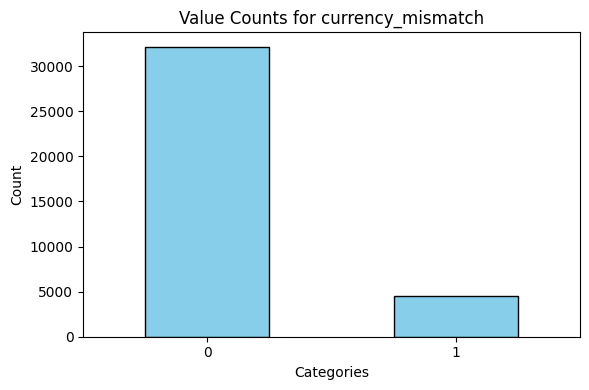

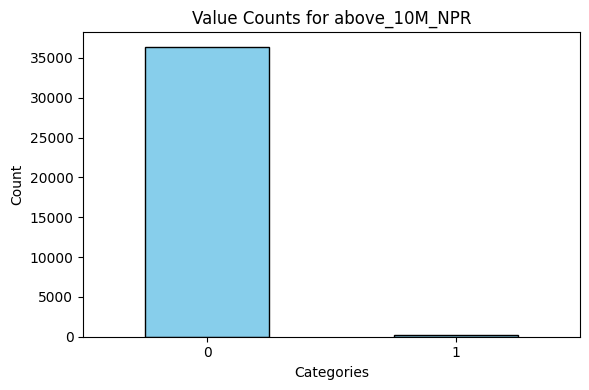

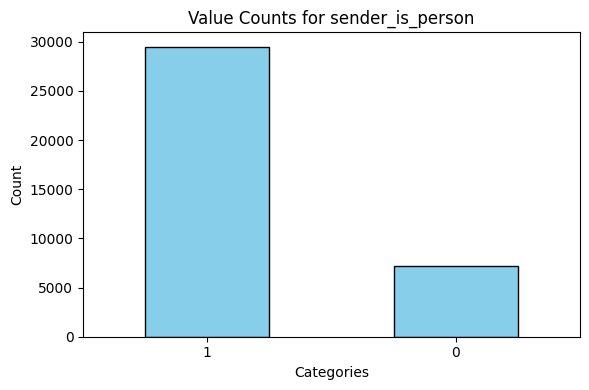

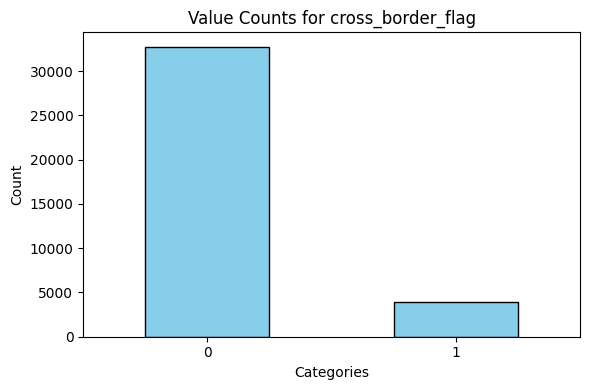

In [17]:
cols = ['currency_mismatch', 'above_10M_NPR', 'sender_is_person', 'cross_border_flag']

for label in cols:
    plt.figure(figsize=(6, 4))
    df[label].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')

    plt.title(f'Value Counts for {label}')
    plt.ylabel('Count')
    plt.xlabel('Categories')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

Feature Correlations with Fraud Label

A quick look at which raw features already correlate with suspicious transactions before we do any engineering.

/tmp/ipykernel_2278/160968000.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')


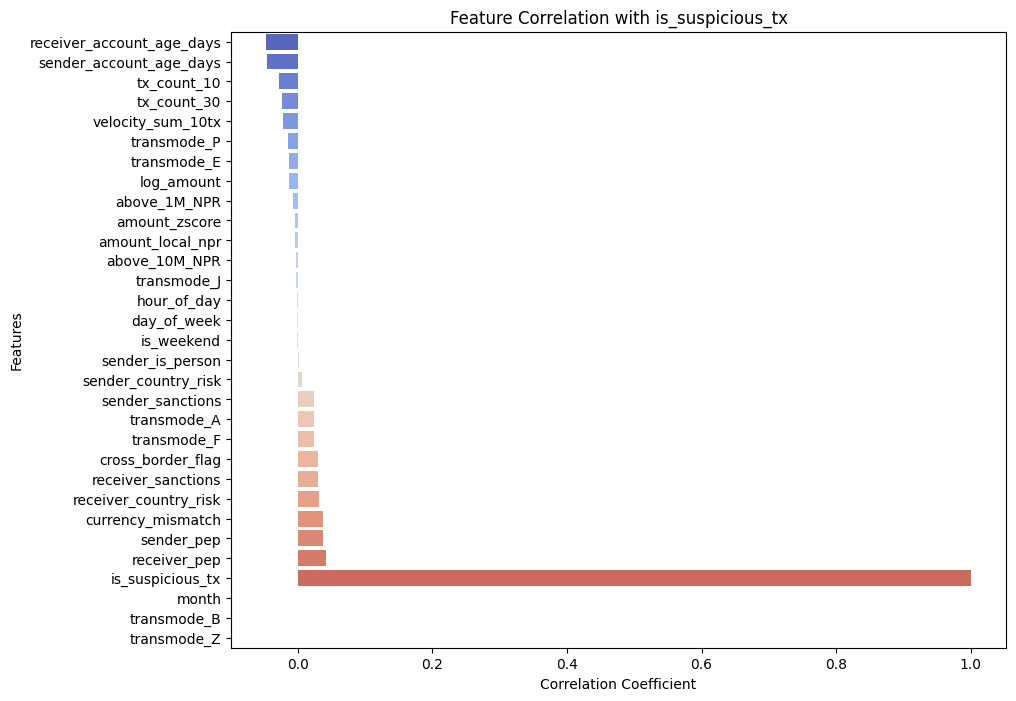

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['Sender_account', 'Receiver_account']]

correlations = df[numeric_cols].corr()['is_suspicious_tx'].sort_values()

plt.figure(figsize=(10, 8))
sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')
plt.title('Feature Correlation with is_suspicious_tx')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.show()